In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import scipy
from scipy import integrate
import sys

In [2]:
plt.rcParams.update({'font.size': 14})

In [ ]:
# Physical constants and particle properties
v_c = 3e8              # speed of light in vacuum (m/s)

# Particle masses (in eV)
m_pi = 139.57039e6     # charged pion mass
m_mu = 105.6583755e6   # muon mass

# Muon momentum and energy in the pion rest frame (center-of-mass frame)
# Derived from two-body decay kinematics: π → μ + ν
P_mu_CM = np.sqrt((m_pi**2 + m_mu**2)**2 - (2*m_pi*m_mu)**2) / (2*m_pi)  # muon momentum
E_mu_CM = (m_pi**2 + m_mu**2) / (2*m_pi)                                 # muon energy

# Mean lifetimes (in seconds)
tau_pi = 2.6e-8        # pion mean decay time
tau_mu = 2.196981e-6   # muon mean decay time

# Function definitions

In [4]:
def Beta_r(p, m, tau):
    # Relativistic kinematics and decay length calculation
    # p   : particle momentum (eV/c in natural units where c=1)
    # m   : particle mass (eV)
    # tau : proper (rest-frame) mean lifetime (s)

    # Total energy from relativistic energy-momentum relation: E^2 = p^2 + m^2
    E = np.sqrt(p**2 + m**2)

    # Lorentz factor (time dilation factor)
    gamma = E / m

    # Velocity as a fraction of speed of light (v/c)
    beta = p / E

    # Dilated lifetime in the lab frame: t = γτ
    t = gamma * tau

    # Mean decay length in the lab frame: L = v * t = βc * γτ
    L_l = v_c * t

    return beta, L_l

In [23]:
def R_nu(p_pi, p_mu, a, d, R, delta_max, label, *, s_array=s_array, width=width):
    # Compute neutrino rate
    # including decay probabilities, geometric acceptance, and momentum acceptance.
    #
    # Inputs:
    # p_pi      : pion momentum
    # p_mu      : selected muon momentum
    # a, d, R   : geometry parameters of the beamline / detector system (m)
    # delta_max : fractional momentum acceptance half range
    # label     : label for plotting
    #
    # Units:
    # momentum in eV, distance in m

    # Physical check: parent pion momentum must be at least as large as muon momentum
    if p_pi >= p_mu:

        # Compute beta=v/c and mean decay length for pion and muon
        beta_pi, L_l_pi = Beta_r(p=p_pi, m=m_pi, tau=tau_pi)
        beta_mu, L_l_mu = Beta_r(p=p_mu, m=m_mu, tau=tau_mu)

        # Effective decay lengths scaled by beta
        L_pi = beta_pi * L_l_pi
        L_mu = beta_mu * L_l_mu

        print('Muon decay length is ', L_mu, 'm.')

        # Lorentz factor of the pion in the lab frame
        gamma_pi = 1 / np.sqrt(1 - beta_pi**2)

        # Extreme muon momenta in the lab frame from two-body decay kinematics
        # min: backward emission in pion CM frame
        # max: forward emission in pion CM frame
        P_mu_lab_min = gamma_pi * (P_mu_CM * np.cos(np.pi) + beta_pi * E_mu_CM)
        P_mu_lab_max = gamma_pi * (P_mu_CM * np.cos(0)     + beta_pi * E_mu_CM)

        # Fraction of the muon momentum spectrum accepted by the ring
        momentum_acc = 2 * delta_max * p_mu / (P_mu_lab_max - P_mu_lab_min)

        # Approximate expression for momentum acceptance (kept here for reference)
        # momentum_acc = 7 * p_mu * 2 * delta_max / (3 * p_pi)

        # Check whether requested muon momentum is kinematically allowed
        if (P_mu_lab_min < p_mu < P_mu_lab_max):

            # ---------- helpers ----------
            def integrand(x, s):
                # theta: angle subtended by detector radius R at decay position x
                theta = np.arctan(R / (d + s - x))

                # Survival probability that muon has not decayed before position x
                f1 = np.exp(-x / L_mu)

                # Angular acceptance factor for neutrinos emitted in the forward direction
                f2 = 1 / 2 * (1 + beta_mu) * (1 - np.cos(theta)) / (1 - beta_mu * np.cos(theta))

                return f1 * f2

            # ---------- scan over s ----------
            # Numerically evaluate acceptance as a function of decay channel length s
            f3_int = []
            for s in s_array:
                x = np.arange(0, s, width)   # grid, not used directly in fixed_quad
                integral, _ = integrate.fixed_quad(lambda x: integrand(x, s), 0, s, n=99)

                # Straight-to-curved section transfer factor
                S2C = 1 / (2 * (1 + a / s))

                # Probability that the pion decays within length s
                f_pi_decay = (1 - np.exp(-s / L_pi))

                # Normalize muon decay probability over the interval
                C_normalisation = 1 / (L_mu * (1 - np.exp(-s / L_mu)))

                # Total contribution for this value of s
                f3 = integral * C_normalisation * S2C * f_pi_decay
                f3_int.append(f3)

            # Convert results to array
            P = np.array(f3_int)

            # Find s giving maximum neutrino rate / acceptance
            S_max = s_array[np.argwhere(P == max(P))]
            print(f'R_nu maximum at s = {S_max.item():.2f}m.')

            # Plot acceptance curve and its maximum point
            plt.plot(s_array, P, label=label)
            plt.plot(S_max, max(P), '*')

            return P, momentum_acc

        else:
            # Requested muon momentum is outside allowed decay kinematics
            print('p_pi cannot decay to muon with this p_mu!')
            print('Min p_mu is', P_mu_lab_min / 1e6, 'MeV')
            print('Max p_mu is', P_mu_lab_max / 1e6, 'MeV')
            sys.exit()

    else:
        # Unphysical case: daughter momentum larger than parent momentum
        print("p_pi must >= p_mu !")
        sys.exit()

In [18]:
def Rnu_at_s(R_nu, s):
    return R_nu[np.argwhere(np.round(s_array, 2)==s)]

# Example

In [19]:
width = 0.05
s_array = np.arange(0.1, 1000, width)

Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 89.40m.
Muon decay length is  13723.544897772917 m.
R_nu maximum at s = 173.20m.
Muon decay length is  18713.924860599433 m.
R_nu maximum at s = 238.10m.
Muon decay length is  23704.304823425948 m.
R_nu maximum at s = 303.20m.
Muon decay length is  23704.304823425948 m.
R_nu maximum at s = 750.15m.


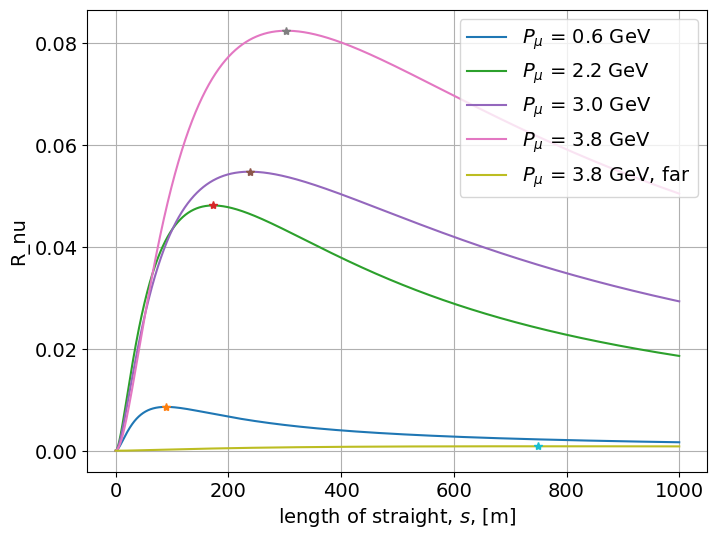

In [24]:
plt.figure(figsize=(8,6))

Rnu_mu600, mo_acc600    = R_nu(p_pi=1000e6, p_mu=600e6, a=27, d=50, R=2.5, delta_max=0.1, label = rf'$P_\mu$ = {0.6} GeV')
Rnu_mu2200, mo_acc2200  = R_nu(p_pi=3000e6, p_mu=2200e6, a=27, d=50, R=2.5, delta_max=0.1, label = rf'$P_\mu$ = {2.2} GeV')
Rnu_mu3000, mo_acc3000  = R_nu(p_pi=5000e6, p_mu=3000e6, a=27, d=50, R=2.5, delta_max=0.1, label = rf'$P_\mu$ = {3.0} GeV')
# Rnu_mu3800me, mo_acc3800me  = R_nu(p_pi=5000e6, p_mu=3800e6, a=27, d=50, R=2.5, delta_max=0.1, label = rf'$P_\mu$ = {3.0} GeV')

Rnu_mu3800, mo_acc3800         = R_nu(p_pi=5e9, p_mu=3.8e9, a=59.8, d=50,   R=3, delta_max=0.1, label=rf'$P_\mu$ = {3.8} GeV')
Rnu_mu3800_far, mo_acc3800_far = R_nu(p_pi=5e9, p_mu=3.8e9, a=59.8, d=2050, R=3, delta_max=0.1, label=rf'$P_\mu$ = {3.8} GeV, far')


plt.xlabel(f'length of straight, $s$, [m]')
plt.ylabel('R_nu')
# plt.vlines(x=50, ymin=0, ymax=0.07)
plt.grid()
plt.legend()

Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 89.40m.
Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 79.80m.
Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 76.15m.
Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 91.10m.
Muon decay length is  3742.784972119886 m.
R_nu maximum at s = 69.90m.


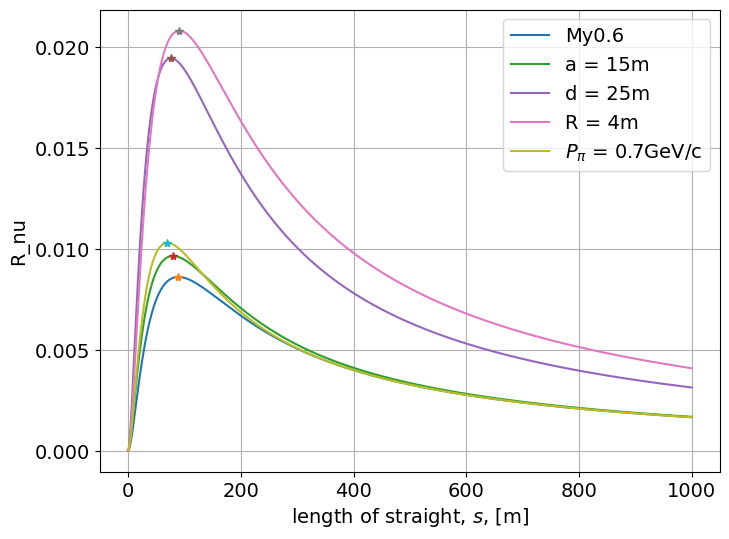

In [24]:
plt.figure(figsize=(8,6))

Rnu_mu600, mo_acc600  = R_nu(p_pi=1000e6, p_mu=600e6, a=27, d=50, R=2.5, delta_max=0.1, label = rf'My0.6')
Rnu_mu600, mo_acc600  = R_nu(p_pi=1000e6, p_mu=600e6, a=15, d=50, R=2.5, delta_max=0.1, label = rf'a = 15m')
Rnu_mu600, mo_acc600  = R_nu(p_pi=1000e6, p_mu=600e6, a=27, d=25, R=2.5, delta_max=0.1, label = rf'd = 25m')
Rnu_mu600, mo_acc600  = R_nu(p_pi=1000e6, p_mu=600e6, a=27, d=50, R=4, delta_max=0.1, label = rf'R = 4m')
Rnu_mu600, mo_acc600  = R_nu(p_pi=601e6, p_mu=600e6, a=27, d=50, R=2.5, delta_max=0.1, label = r'$P_{\pi}$ = 0.7GeV/c')



plt.xlabel(f'length of straight, $s$, [m]')
plt.ylabel('R_nu')
# plt.vlines(x=50, ymin=0, ymax=0.07)
plt.grid()
plt.legend()

In [28]:
N_pi = 600e3
ring_eff6 = 0.5    #  0.85
N_nu_2200 = N_pi * Rnu_at_s(Rnu_mu2200, 81) * mo_acc2200 * ring_eff6
N_nu_2200

array([[4061.12943454]])

In [30]:
## remember to remove in the formula f_pi when you do this!
N_p = 1e21
N_pi = N_p*0.011 # 0.011: muons after straight
ring_eff = 0.5 #.87 
N_nu_3800 = N_pi*Rnu_at_s(Rnu_mu3800, 180)*ring_eff/0.47490234846821777
print(N_nu_3800/(3**2*np.pi),'per m^2')

[[3.05255616e+16]] per m^2
